Tests out the computer vision side of things, thresholding, dot recognition, color recognition.

In [1]:
import cv2 as cv

In [16]:
def camera( imgOrVid:str = "",runNumber:int = 0, grabFrames:bool= False, grabFrameRate:int =10):
    ''''
    Runs webcam and gets the input
    If you want a singular photo taken, set imgOrVid to "image", else it will start a video
    Please set the run number according to which run you want to store this as.
    If you want to store frames from the video, set grabFrames to true, else it will not store anything
    Set the grabFrameRate for videos, to decide at what rate to grab frames.
    '''
    ## Grabbed base code from https://stackoverflow.com/questions/2601194/displaying-a-webcam-feed-using-opencv-and-python
    vc = cv.VideoCapture(0) # input index is 0, so first video input I assume 
    # returns a viedos capture object called vc
    if vc.isOpened(): # try to get the first frame
        print('open')
        rval, frame = vc.read() # returns a value (boolean I think? true) and frame
        print(rval)
        if imgOrVid == "image" and rval != False: ## if image is the input, takes a singular photo
            print("say cheese")
            cv.imwrite(f"frames/run{runNumber}snapshot.jpg", frame)
        else: ## otherwise start a camera feed
            count = 0
            while rval:
                cv.imshow("preview", frame)
                rval, frame = vc.read() 
                # returns the retreval value and the image
                # combines grab and retrive in one call. if nothing grabbed, returns false.
                if count % grabFrameRate == 0 and grabFrames == True and rval != False: 
                ## if grabframes is true, then store frames from the camera feed at the rate specified
                    cv.imwrite(f"frames/run{runNumber}frame{count}.jpg", frame) 
                    ## this is storing all of them in the frames folder under rum#frame#.jpg
                count +=1
                key = cv.waitKey(20)
                print(key)
                if key == 27: # exit on ESC
                    print("exiting")
                    break
    else:
        rval = False
    print("broke loop")
    cv.destroyWindow("preview")
    print("test this")
   

In [ ]:
# camera("video")
# breaks in jupyter notebook, fine in python file

In [20]:
camera("image",5,True,10)

open
True
say cheese
broke loop
test this


test_dots.png


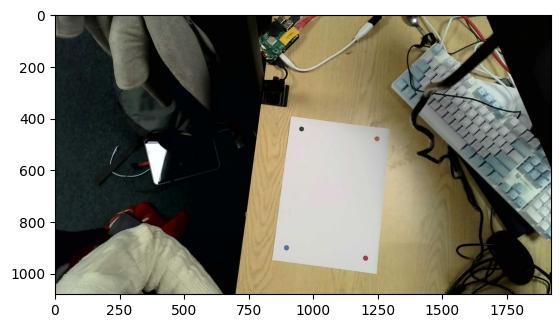

Gray Scale


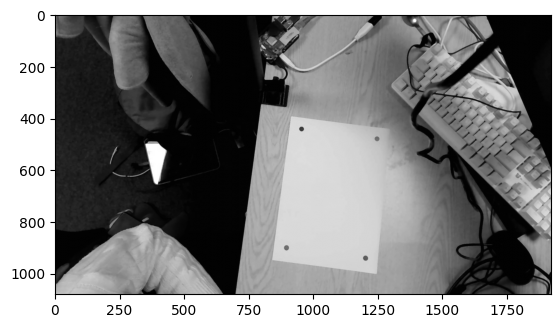

Thresholded


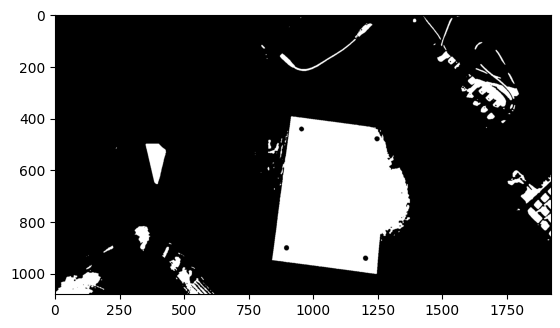

Blobs detected


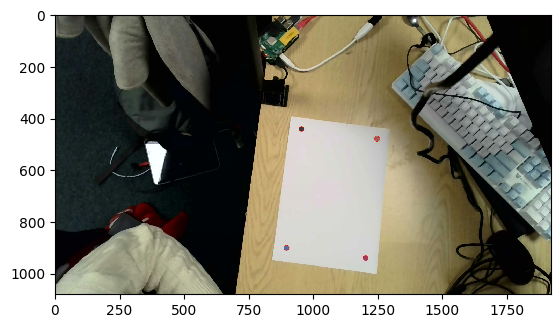

In [ ]:
from pathlib import Path
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

img_path = Path("frames/seta.jpg")

image = cv.imread(img_path, cv.IMREAD_COLOR_RGB)
print("test_dots.png")
plt.imshow(image)
plt.show()


image = cv.medianBlur(image, 5)
gray = cv.cvtColor(image, cv.COLOR_RGBA2GRAY)
print("Gray Scale")
plt.imshow(gray, cmap="gray")
plt.show()

_, thesholded = cv.threshold(gray, 180, 255, cv.THRESH_BINARY)
print("Thresholded")
plt.imshow(thesholded, cmap="gray")
plt.show()

params = cv.SimpleBlobDetector_Params()
params.filterByCircularity = True
params.minCircularity = 0.5
params.minArea=100
detector = cv.SimpleBlobDetector_create(params)
keypoints = detector.detect(thesholded)


blank = np.zeros((1, 1))
blobs = cv.drawKeypoints(
    image, keypoints, blank, (255, 0, 0), cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

print("Blobs detected")
plt.imshow(blobs, interpolation="nearest")
plt.show()

False


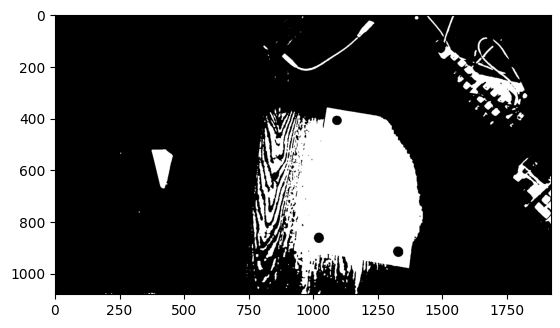

Blobs detected


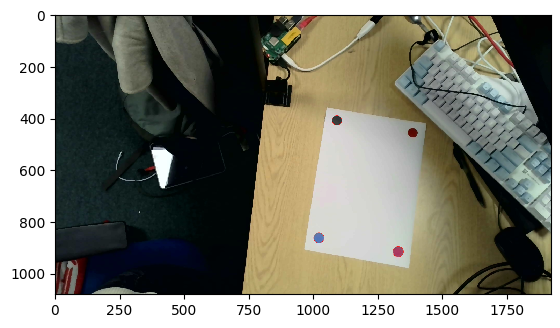

True


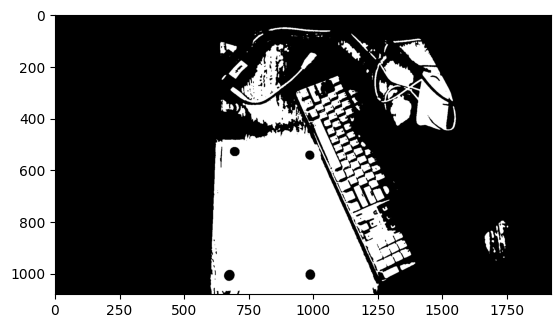

Blobs detected


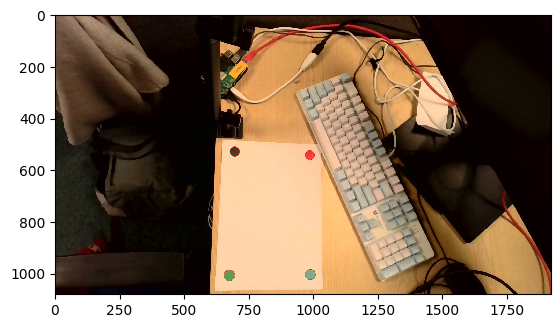

False


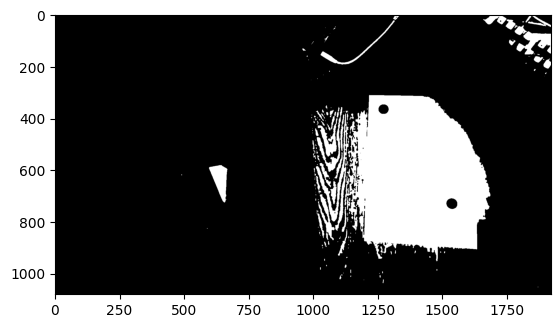

Blobs detected


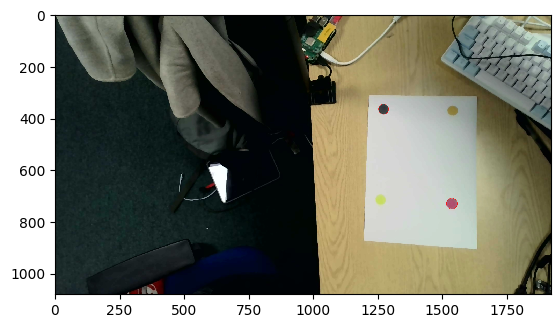

True


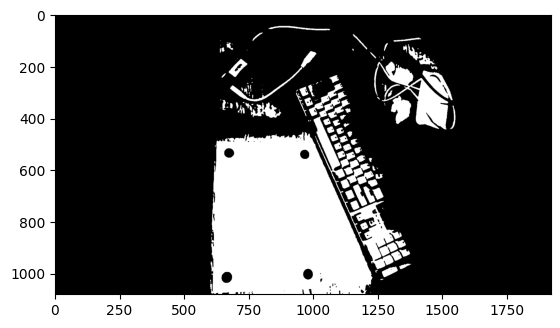

Blobs detected


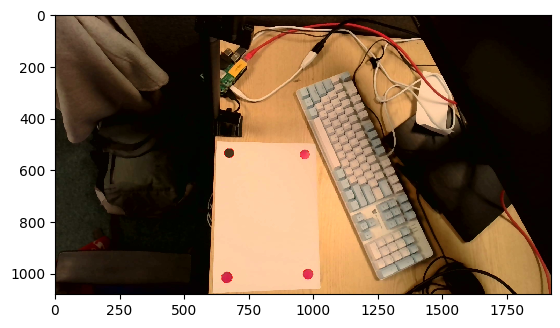

    setA1  setB1  setC1  setD1
0     0.0    0.0    0.0    0.0
1     0.0    0.0    0.0    0.0
2     0.0    0.0    0.0    0.0
3     0.0    0.0    0.0    0.0
4     0.0    0.0    0.0    0.0
5     0.0    0.0    0.0    0.0
6     0.0    0.0    0.0    0.0
7     0.0    0.0    0.0    0.0
8     0.0    0.0    0.0    0.0
9     0.0    0.0    0.0    0.0
10    0.0    0.0    0.0    0.0
11    0.0    0.0    0.0    0.0
12    0.0    0.0    0.0    0.0
13    0.0    0.0    0.0    0.0
14    0.0    0.0    0.0    0.0
15    0.0    0.0    0.0    0.0
16    0.0    0.0    0.0    0.0
17    0.0    0.0    0.0    0.0
18    0.0    0.0    0.0    0.0
19    0.0    0.0    0.0    0.0
20    0.0    0.0    0.0    0.0
21    0.0    0.0    0.0    0.0
22    0.0    0.0    0.0    0.0
23    0.0    0.0    0.0    0.0
24    0.0    0.0    0.0    1.0
25    1.0    0.0    0.0    0.0
26    1.0    1.0    0.0    0.0
27    1.0    1.0    0.0    0.0
28    1.0    0.0    0.0    0.0
29    0.0    0.0    0.0    0.0
30    0.0    1.0    0.0    1.0
31    0.

In [ ]:
from pathlib import Path
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

imageSet = ["setDarkA", "setDarkB", "setDarkC", "setDarkD"]

sucessDict = {}

for img in imageSet:
    img_path = Path("frames/" + img + ".jpg")
    image = cv.imread(img_path, cv.IMREAD_COLOR_RGB)
    sucesses = np.zeros(51)
    for i in range(0,255, 5):
        image = cv.imread(img_path, cv.IMREAD_COLOR_RGB)
        image = cv.medianBlur(image, 5)
        gray = cv.cvtColor(image, cv.COLOR_RGBA2GRAY)
        _, thesholded = cv.threshold(gray, i, 255, cv.THRESH_BINARY)
        params = cv.SimpleBlobDetector_Params()
        params.filterByCircularity = True
        params.minCircularity = 0.5
        params.minArea=300
        detector = cv.SimpleBlobDetector_create(params)
        keypoints = detector.detect(thesholded)
        blank = np.zeros((1, 1))
        blobs = cv.drawKeypoints(
            image, keypoints, blank, (255, 0, 0), cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
        )
        if len(keypoints) == 4:
            sucesses[int(i/5)] = 1
        if i == 170:
            print(len(keypoints) == 4)
            plt.imshow(thesholded, cmap="gray")
            plt.show()
            print("Blobs detected")
            plt.imshow(blobs, interpolation="nearest")
            plt.show()
            
    sucessDict.update({img:sucesses})

sucessDF = pd.DataFrame(sucessDict)
print(pd.DataFrame(sucessDF))
sucessDF.to_csv('sucessDF1.csv')



In [7]:
test = [i for i in range(0,255, 5)]
for x in test:
    print(x/5)

0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0
21.0
22.0
23.0
24.0
25.0
26.0
27.0
28.0
29.0
30.0
31.0
32.0
33.0
34.0
35.0
36.0
37.0
38.0
39.0
40.0
41.0
42.0
43.0
44.0
45.0
46.0
47.0
48.0
49.0
50.0


In [ ]:
tes2t = np.zeros(51)
len(tes2t)


51

In [10]:
for kp in keypoints:
    print(kp.pt)

print(len(keypoints))

(1199.3902587890625, 941.461669921875)
(1905.242431640625, 857.0800170898438)
(1719.5933837890625, 656.5144653320312)
(952.0318603515625, 443.0149841308594)
4


In [ ]:
from dataclasses import dataclass
from math import hypot


@dataclass
class Point:
    x: float = 0.0
    y: float = 0.0

    @classmethod
    def from_tuple(cls, coords):
        return cls(coords[0], coords[1])

    def as_tuple(self):
        return (self.x, self.y)


def euc_dist(a: Point, b: Point) -> float:
    return hypot(b.x - a.x, b.y - a.y)


points = [Point.from_tuple(kp.pt) for kp in keypoints]

print(f"There are {len(points)} points in the image.")

In [ ]:
# lets test out the finding rectangles stuff
from itertools import combinations


# util function used to put the distances into buckets
def bucket(value: float, size: float):
    return int(value / size)


# compute all the unordered pairs
pairs = list(combinations(points, 2))

print(f"There are {len(pairs)} pairs of points.")
pairs

In [ ]:
# work out the distances between each pair
bucketed = [bucket(euc_dist(a, b), 5) for a, b in pairs]

print(f"There are {len(list(set(bucketed)))} pairs of different distances.")

In [ ]:
# find the lines with approx the same lengths
from collections import defaultdict


tally = defaultdict(list)

for pair, dist in zip(pairs, bucketed):
    tally[dist].append(pair)
same_distance_pairs = dict(
    ((dist, pairs) for dist, pairs in tally.items() if len(pairs) > 1)
)
same_distance_pairs
print(tally)